# Phân tích Kết hợp GLDAS-Noah & CHIRPS (2019-2024) cho Đồng bằng sông Cửu Long

Notebook này tổng hợp hai nguồn dữ liệu khí hậu-thủy văn quan trọng: GLDAS-Noah (độ ẩm đất, năng lượng bề mặt) và CHIRPS (lượng mưa) để khám phá insight phục vụ đề tài dự báo năng suất lúa ĐBSCL.

## Mục tiêu EDA
- Hiểu mối liên hệ giữa **nước sẵn có trong đất** và **lượng mưa nền**.
- So sánh sự khác biệt giữa các nhóm tỉnh (thượng nguồn vs ven biển) trong bối cảnh **xâm nhập mặn, hạn hán** (tham chiếu README).
- Nhận diện các giai đoạn bất thường (hạn kéo dài, mưa cực đoan) và ảnh hưởng tới độ ẩm vùng rễ.
- Chuẩn bị insight định tính cho bài toán dự báo năng suất lúa mà **không cần tiền xử lý** hay biến đổi đặc trưng.

## Nội dung chính
1. Thiết lập môi trường và tải
2. Khảo sát cấu trúc, chất lượng dữ liệu
3. Phân tích đơn biến (mưa, độ ẩm, năng lượng)
4. Phân tích song biến & liên kết mưa - ẩm
5. Phân tích đa biến & phân cụm tỉnh
6. Tổng kết insight theo chủ đề luận văn

In [ ]:
import warnings

warnings.filterwarnings("ignore")


In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.tsa.seasonal import STL
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
np.random.seed(42)

print("✓ Thư viện đã sẵn sàng")


✓ Thư viện đã sẵn sàng


In [ ]:
BASE_DIR = Path.cwd()
GLDAS_DIR = BASE_DIR / "dataset" / "natural" / "gldas"
PRECIP_DIR = BASE_DIR / "dataset" / "natural" / "precipitation"
OUTPUT_DIR = BASE_DIR / "output" / "eda_combined"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

gldas_csv = GLDAS_DIR / "gldas_mekong_delta_2019_2024_full.csv"
precip_csv = PRECIP_DIR / "chirps_mekong_delta_2019_2024_full.csv"
gldas_meta = GLDAS_DIR / "metadata.json"
precip_meta = PRECIP_DIR / "metadata.json"


In [ ]:
df_gldas = pd.read_csv(gldas_csv)
df_precip = pd.read_csv(precip_csv)

print("GLDAS shape:", df_gldas.shape)
print("CHIRPS shape:", df_precip.shape)
df_gldas.head()


GLDAS shape: (28496, 38)
CHIRPS shape: (28496, 3)


,province,date,Albedo_inst,AvgSurfT_inst,CanopInt_inst,ECanop_tavg,ESoil_tavg,Evap_tavg,LWdown_f_tavg,Lwnet_tavg,...,SoilMoi10_40cm_inst,SoilMoi40_100cm_inst,SoilTMP0_10cm_inst,SoilTMP100_200cm_inst,SoilTMP10_40cm_inst,SoilTMP40_100cm_inst,Swnet_tavg,Tair_f_inst,Tveg_tavg,Wind_f_inst
0,Soc Trang,2019-01-01,15.064176,296.116210,0.257861,31.123575,48.354889,0.000043,422.840910,-12.606521,...,109.483582,222.052965,296.988799,299.784654,298.973396,299.460783,72.072214,297.177087,29.091923,4.949059
1,Soc Trang,2019-01-02,15.046503,295.184524,0.499870,55.129715,48.429627,0.000041,415.283950,-14.500901,...,119.739326,227.769187,295.883946,299.772967,298.485258,299.381557,85.444306,295.725244,0.000202,6.319528
2,Soc Trang,2019-01-03,15.032153,297.402127,0.492814,66.882153,61.510069,0.000051,406.891451,-34.385217,...,121.098372,238.944090,297.146986,299.756565,298.251014,299.262356,123.494097,298.230100,0.183332,6.701585
3,Soc Trang,2019-01-04,15.017210,298.247638,0.272502,52.087458,71.429661,0.000059,396.353801,-50.506378,...,119.247282,239.034454,298.235860,299.735344,298.403681,299.168705,151.358240,299.458283,25.144652,6.677373
4,Soc Trang,2019-01-05,14.999537,298.353805,0.046923,10.364185,71.103222,0.000057,374.329173,-72.841701,...,115.131874,235.381042,298.508252,299.711972,298.590338,299.120141,203.494508,299.504699,64.742871,5.563865


In [ ]:
df_precip.head()


,province,date,precipitation
0,Soc Trang,2019-01-01,8.083463
1,Soc Trang,2019-01-02,7.313124
2,Soc Trang,2019-01-03,2.128573
3,Soc Trang,2019-01-04,0.399126
4,Soc Trang,2019-01-05,0.000000


In [ ]:
with open(gldas_meta, "r", encoding="utf-8") as f:
    meta_gldas = json.load(f)
with open(precip_meta, "r", encoding="utf-8") as f:
    meta_precip = json.load(f)

print("Số biến GLDAS:", len(meta_gldas))
print("Thông tin biến mưa:", meta_precip)


Số biến GLDAS: 36
Thông tin biến mưa: {'precipitation': {'unit': 'mm', 'description': 'Lượng mưa hàng ngày'}}


### Chuẩn hóa cột thời gian & thiết lập chỉ mục đa cấp
Các thao tác này chỉ nhằm mục đích EDA (đơn vị giữ nguyên theo README).

In [ ]:
df_gldas["date"] = pd.to_datetime(df_gldas["date"])
df_precip["date"] = pd.to_datetime(df_precip["date"])

gldas_numeric = df_gldas.columns.difference(["date", "province"])
df_gldas[gldas_numeric] = df_gldas[gldas_numeric].apply(pd.to_numeric, errors="coerce")
df_precip["precipitation"] = pd.to_numeric(df_precip["precipitation"], errors="coerce")

df_gldas = (
    df_gldas.drop_duplicates(subset=["province", "date"])
    .set_index(["province", "date"])
    .sort_index()
)
df_precip = (
    df_precip.drop_duplicates(subset=["province", "date"])
    .set_index(["province", "date"])
    .sort_index()
)

print(df_gldas.index.names)
print(df_precip.index.names)


['province', 'date']
['province', 'date']


In [ ]:
def summarize_missing(df):
    miss = df.isna().sum()
    pct = miss / len(df) * 100
    return pd.DataFrame({"missing": miss, "pct": pct}).sort_values(
        "pct", ascending=False
    )


missing_gldas = summarize_missing(df_gldas)
missing_precip = summarize_missing(df_precip)
missing_gldas.head(10)


,missing,pct
Albedo_inst,0,0.0
AvgSurfT_inst,0,0.0
CanopInt_inst,0,0.0
ECanop_tavg,0,0.0
ESoil_tavg,0,0.0
Evap_tavg,0,0.0
LWdown_f_tavg,0,0.0
Lwnet_tavg,0,0.0
PotEvap_tavg,0,0.0
Psurf_f_inst,0,0.0


In [ ]:
missing_precip.head()


,missing,pct
precipitation,0,0.0


## Tổng quan dữ liệu
- Thời gian quan sát: xem kết quả in ở cell kế tiếp (min → max).
- 13 tỉnh/thành Đồng bằng sông Cửu Long.
- Bộ GLDAS bao gồm 38 biến thủy văn-khí tượng.
- Biến lượng mưa đại diện: `precipitation` (mm) từ CHIRPS.

In [ ]:
time_range = (
    df_gldas.index.get_level_values("date").min(),
    df_gldas.index.get_level_values("date").max(),
)
province_list = sorted(df_gldas.index.get_level_values("province").unique())
print(f"Thời gian: {time_range[0].date()} → {time_range[1].date()}")
print(f"Số tỉnh: {len(province_list)}")
print("Các tỉnh:", province_list)


Thời gian: 2019-01-01 → 2024-12-31
Số tỉnh: 13
Các tỉnh: ['An Giang', 'Bac Lieu', 'Ben Tre', 'Ca Mau', 'Can Tho city', 'Dong Thap', 'Hau Giang', 'Kien Giang', 'Long An', 'Soc Trang', 'Tien Giang', 'Tra Vinh', 'Vinh Long']


## 1. Phân tích đơn biến
### Lượng mưa hàng ngày (CHIRPS)

In [ ]:
fig = px.histogram(
    df_precip.reset_index(),
    x="precipitation",
    nbins=120,
    title="Phân phối lượng mưa hàng ngày (mm)",
)
fig.update_layout(xaxis_title="mm", yaxis_title="Số ngày")
fig.show()


### Độ ẩm đất & năng lượng bề mặt (GLDAS)

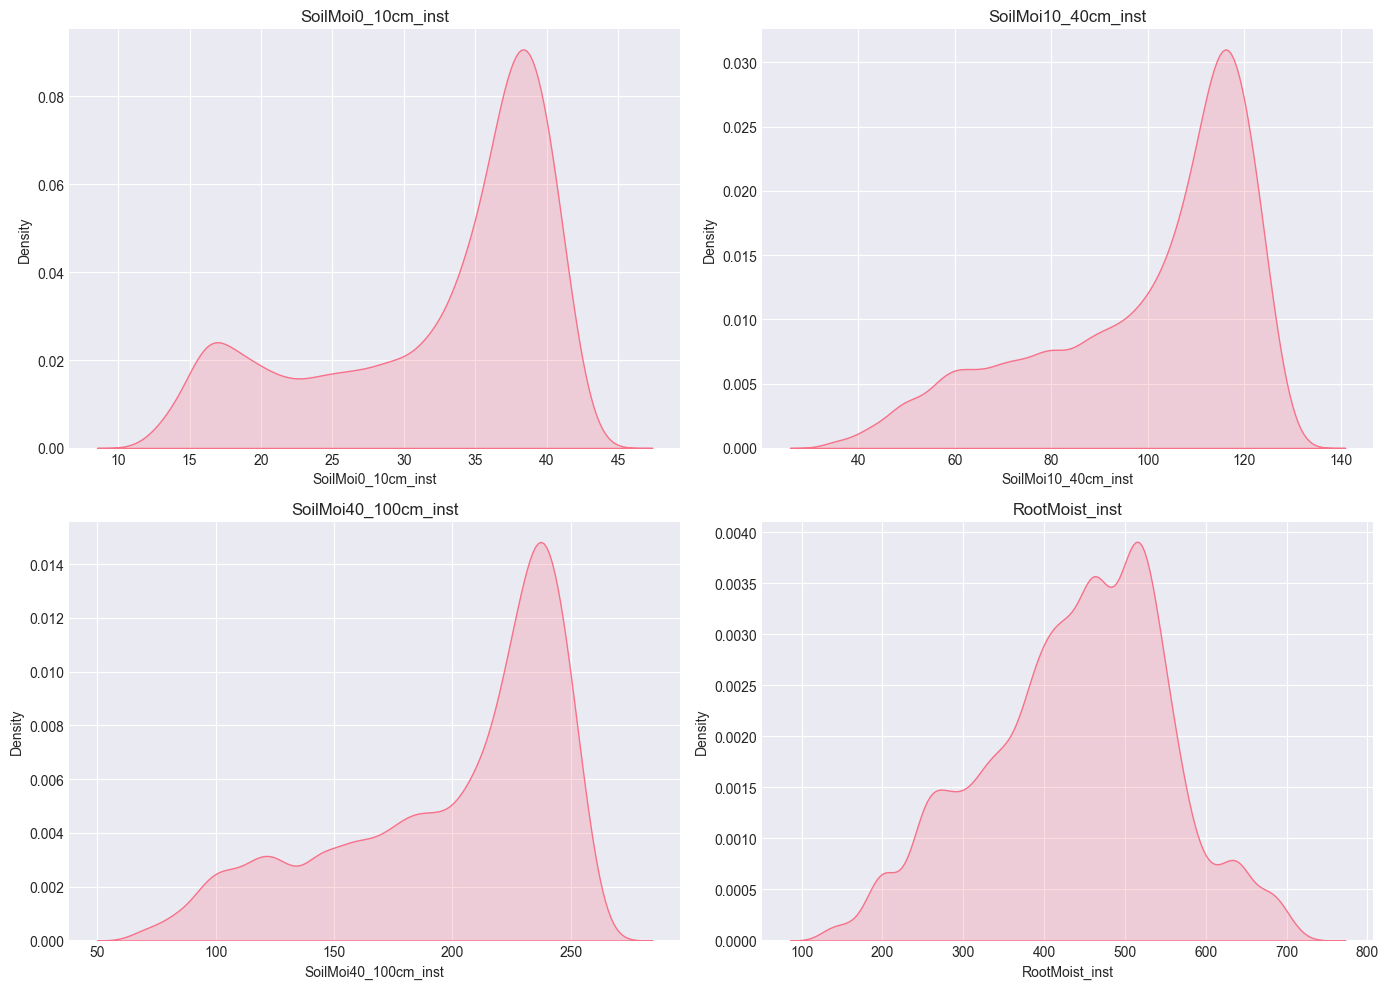

In [ ]:
soil_cols = [
    "SoilMoi0_10cm_inst",
    "SoilMoi10_40cm_inst",
    "SoilMoi40_100cm_inst",
    "RootMoist_inst",
]
energy_cols = ["Swnet_tavg", "SWdown_f_tavg", "Evap_tavg", "Qh_tavg", "Qle_tavg"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat, soil_cols[:4]):
    sns.kdeplot(df_gldas[col].dropna(), ax=ax, fill=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [ ]:
summary_stats = df_gldas[soil_cols + energy_cols].describe().T
summary_stats[["mean", "std", "min", "max"]].round(3)


,mean,std,min,max
SoilMoi0_10cm_inst,32.320,8.177,11.682,44.247
SoilMoi10_40cm_inst,99.588,21.955,34.280,132.524
SoilMoi40_100cm_inst,199.078,47.644,68.269,266.142
RootMoist_inst,439.581,113.153,129.170,729.106
Swnet_tavg,176.934,43.216,32.793,262.603
SWdown_f_tavg,207.236,50.663,38.405,305.723
Evap_tavg,0.000,0.000,0.000,0.000
Qh_tavg,21.261,38.126,-98.330,141.507
Qle_tavg,106.572,38.746,9.400,249.374


## 2. Xu hướng thời gian
### Trung bình tháng toàn vùng

In [ ]:
monthly_precip = df_precip.groupby(pd.Grouper(level="date", freq="M"))[
    "precipitation"
].mean()
monthly_soil = df_gldas.groupby(pd.Grouper(level="date", freq="M"))[
    "SoilMoi0_10cm_inst"
].mean()
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    subplot_titles=["Lượng mưa trung bình tháng", "Độ ẩm đất 0-10cm trung bình tháng"],
)
fig.add_trace(
    go.Scatter(x=monthly_precip.index, y=monthly_precip, name="Mưa (mm)"), row=1, col=1
)
fig.add_trace(
    go.Scatter(x=monthly_soil.index, y=monthly_soil, name="Độ ẩm (m³/m³)"), row=2, col=1
)
fig.update_layout(height=600)
fig.show()


### Bảng tổng hợp theo tỉnh

In [ ]:
precip_stats = df_precip["precipitation"].groupby("province").agg(["mean", "sum"])
soil_energy_means = (
    df_gldas[
        [
            "SoilMoi0_10cm_inst",
            "RootMoist_inst",
            "Evap_tavg",
            "Swnet_tavg",
            "Tair_f_inst",
        ]
    ]
    .groupby("province")
    .mean()
)
province_summary = pd.concat([precip_stats, soil_energy_means], axis=1)
province_summary.rename(
    columns={"mean": "precip_mean", "sum": "precip_sum"}, inplace=True
)
province_summary = province_summary.sort_values("precip_sum", ascending=False).round(3)
province_summary


,precip_mean,precip_sum,SoilMoi0_10cm_inst,RootMoist_inst,Evap_tavg,Swnet_tavg,Tair_f_inst
province,,,,,,,
Ca Mau,6.321,13856.169,31.522,543.392,0.0,181.574,300.817
Kien Giang,5.885,12899.416,33.077,450.316,0.0,174.626,300.866
Bac Lieu,5.858,12839.909,33.402,484.688,0.0,172.782,300.857
Hau Giang,5.464,11976.925,34.377,457.916,0.0,172.118,300.676
Soc Trang,5.336,11697.376,31.841,441.133,0.0,173.791,300.774
Long An,4.736,10380.594,31.542,424.553,0.0,184.446,300.964
Can Tho city,4.653,10200.208,34.314,380.234,0.0,175.982,300.719
Vinh Long,4.628,10144.743,31.509,403.740,0.0,174.039,300.611
Tra Vinh,4.556,9986.032,30.267,403.175,0.0,172.990,300.716


In [ ]:
fig = px.bar(
    province_summary.reset_index(),
    x="province",
    y=["precip_sum", "SoilMoi0_10cm_inst", "RootMoist_inst"],
    barmode="group",
    title="So sánh lượng mưa và độ ẩm trung bình theo tỉnh",
)
fig.show()


In [ ]:
combined = df_gldas.join(df_precip, how="inner")
print("Số bản ghi hợp nhất:", len(combined))
combined[["precipitation", "SoilMoi0_10cm_inst", "RootMoist_inst"]].head()


Số bản ghi hợp nhất: 28496


precipitation  SoilMoi0_10cm_inst  RootMoist_inst
province date                                                         
An Giang 2019-01-01       1.821640           34.869654      407.431907
         2019-01-02       8.387930           36.699097      409.249062
         2019-01-03       1.354015           37.504887      414.039908
         2019-01-04       3.177810           38.043608      418.943289
         2019-01-05       0.000000           36.573772      416.349520

## Ma trân tuơng quan giua mua, do am, nang luong

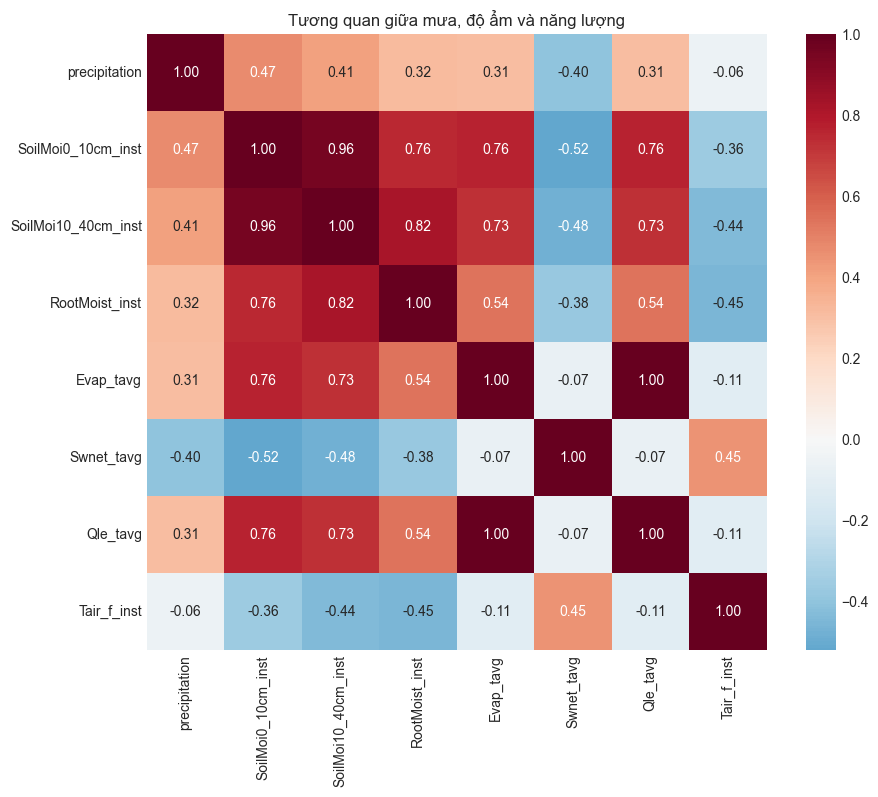

In [ ]:
corr_cols = [
    "precipitation",
    "SoilMoi0_10cm_inst",
    "SoilMoi10_40cm_inst",
    "RootMoist_inst",
    "Evap_tavg",
    "Swnet_tavg",
    "Qle_tavg",
    "Tair_f_inst",
]
corr_matrix = combined[corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Tương quan giữa mưa, độ ẩm và năng lượng")
plt.show()


## Moi quan he giua mua - do am dat

In [ ]:
sample = combined.reset_index().sample(min(8000, len(combined)), random_state=42)
fig = px.scatter(
    sample,
    x="precipitation",
    y="SoilMoi0_10cm_inst",
    color="province",
    trendline="ols",
    title="Mối quan hệ mưa - độ ẩm đất 0-10cm",
)
fig.update_layout(xaxis_title="Mưa (mm)", yaxis_title="Độ ẩm (m³/m³)")
fig.show()


## ti le mua theo thang va do am cua dat

In [ ]:
monthly_combined = (
    combined.groupby([pd.Grouper(level="date", freq="M"), "province"])
    .agg(
        {"precipitation": "sum", "SoilMoi0_10cm_inst": "mean", "RootMoist_inst": "mean"}
    )
    .reset_index()
)
fig = px.scatter(
    monthly_combined,
    x="precipitation",
    y="SoilMoi0_10cm_inst",
    color="province",
    size="RootMoist_inst",
    hover_data=["province", "date"],
    title="Mưa tháng vs Độ ẩm đất (bubble = RootMoist)",
)
fig.update_layout(xaxis_title="Tổng mưa tháng (mm)", yaxis_title="Độ ẩm 0-10cm (m³/m³)")
fig.show()


In [ ]:
pivot_rain = combined["precipitation"].unstack("province")
pivot_soil = combined["SoilMoi0_10cm_inst"].unstack("province")
corr_rain_soil = pivot_rain.corrwith(pivot_soil, axis=0)
corr_rain_soil.sort_values(ascending=False).round(3)


province
Long An         0.522
Dong Thap       0.501
Tien Giang      0.493
Kien Giang      0.490
Ca Mau          0.486
An Giang        0.480
Vinh Long       0.477
Can Tho city    0.470
Bac Lieu        0.468
Soc Trang       0.464
Hau Giang       0.462
Ben Tre         0.462
Tra Vinh        0.447
dtype: float64

In [ ]:
province_focus = "An Giang"
pair = combined.xs(province_focus, level="province")[
    ["precipitation", "SoilMoi0_10cm_inst"]
]
rolling_corr = (
    pair["precipitation"].rolling(60, min_periods=20).corr(pair["SoilMoi0_10cm_inst"])
)
fig = go.Figure()
fig.add_trace(
    go.Scatter(x=rolling_corr.index, y=rolling_corr, name="Hệ số tương quan 60 ngày")
)
fig.add_hline(y=0, line_dash="dash", line_color="gray")
fig.update_layout(
    title=f"Rolling correlation mưa - độ ẩm (60 ngày) tại {province_focus}",
    yaxis_title="Corr",
)
fig.show()


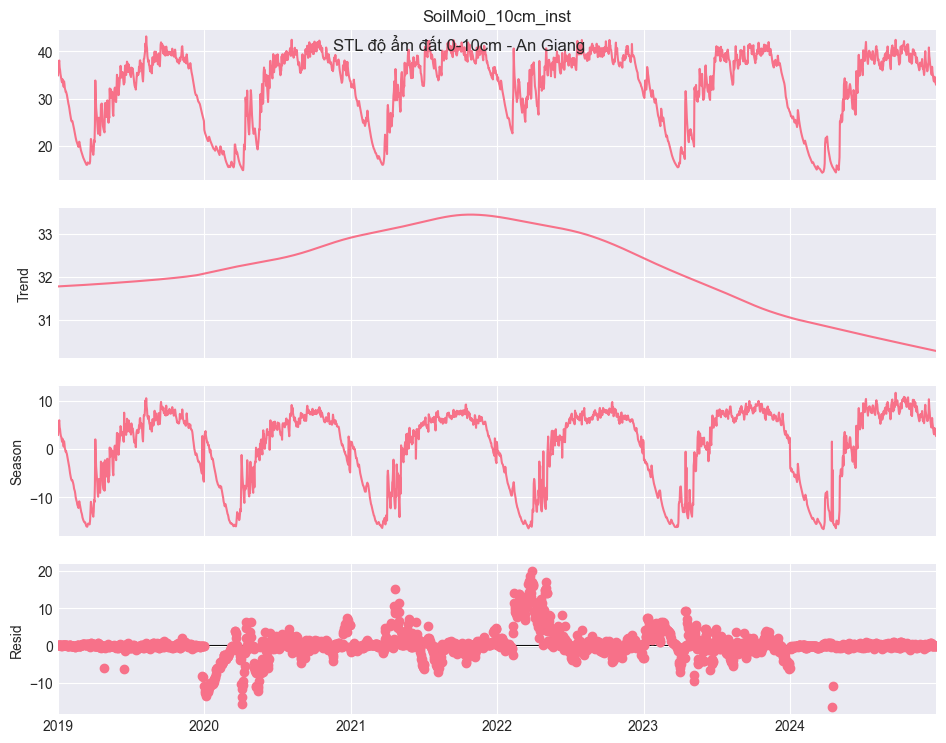

In [ ]:
ts_soil = pair["SoilMoi0_10cm_inst"].asfreq("D").interpolate()
stl = STL(ts_soil, period=365, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(10, 8)
plt.suptitle(f"STL độ ẩm đất 0-10cm - {province_focus}", y=0.92)
plt.show()


In [ ]:
residual = stl.resid
sigma = residual.std()
threshold = 2.5
anomalies = residual[np.abs(residual) > threshold * sigma]
rain_on_anomaly = pair.loc[anomalies.index, "precipitation"]
display(
    pd.DataFrame({"residual": anomalies, "precipitation": rain_on_anomaly}).sort_values(
        "residual"
    )
)
fig = go.Figure()
fig.add_trace(go.Scatter(x=pair.index, y=pair["SoilMoi0_10cm_inst"], name="Độ ẩm"))
fig.add_trace(
    go.Scatter(
        x=anomalies.index,
        y=pair.loc[anomalies.index, "SoilMoi0_10cm_inst"],
        mode="markers",
        marker=dict(color="red", size=9),
        name="Anomaly",
    )
)
fig.add_trace(
    go.Bar(
        x=pair.index,
        y=pair["precipitation"],
        name="Mưa",
        opacity=0.3,
        marker_color="royalblue",
        yaxis="y2",
    )
)
fig.update_layout(
    title="Đối chiếu anomaly độ ẩm với lượng mưa",
    yaxis2=dict(overlaying="y", side="right", title="Mưa (mm)"),
)
fig.show()


,residual,precipitation
date,,
2024-04-15,-16.492608,0.000001
2020-04-03,-15.657326,0.000000
2020-04-04,-13.647770,0.000000
2020-01-04,-13.369824,0.000160
2020-01-03,-12.737174,0.000000
...,...,...
2022-05-02,17.013553,8.352558
2022-03-29,17.073117,4.594657
2022-03-22,17.180606,16.173348


In [ ]:
province_features = combined.groupby("province").agg(
    {
        "precipitation": ["mean", "sum"],
        "SoilMoi0_10cm_inst": "mean",
        "RootMoist_inst": "mean",
        "Evap_tavg": "mean",
        "Swnet_tavg": "mean",
        "Tair_f_inst": "mean",
    }
)
province_features.columns = [
    "_".join(col).strip() for col in province_features.columns.values
]
scaler = StandardScaler()
scaled = scaler.fit_transform(province_features)
pca = PCA(n_components=3, random_state=42)
pca_components = pca.fit_transform(scaled)
explained = pca.explained_variance_ratio_
print("Tỷ lệ phương sai:", np.round(explained * 100, 2))


Tỷ lệ phương sai: [42.97 23.44 18.16]


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
clusters = kmeans.fit_predict(pca_components)
cluster_df = pd.DataFrame({"province": province_features.index, "cluster": clusters})
fig = px.scatter(
    x=pca_components[:, 0],
    y=pca_components[:, 1],
    color=clusters.astype(str),
    text=province_features.index,
    title="Phân cụm tỉnh theo cân bằng nước & năng lượng",
)
fig.update_traces(textposition="top center")
fig.update_layout(xaxis_title="PC1", yaxis_title="PC2")
fig.show()
cluster_df


,province,cluster
0,An Giang,2
1,Bac Lieu,1
2,Ben Tre,0
3,Ca Mau,1
4,Can Tho city,0
5,Dong Thap,2
6,Hau Giang,1
7,Kien Giang,1
8,Long An,2
9,Soc Trang,1


## 6. Insight tổng hợp cho đề tài
1. **Cân bằng nước quyết định sức khỏe ruộng lúa**: Các biến `SoilMoi*` và `RootMoist_inst` dao động mạnh theo mùa và tăng cùng khi mưa tích lũy cao, cho thấy đây là bộ chỉ báo trực tiếp cho tình trạng nước vùng rễ.
2. **Áp lực khô hạn ở ven biển**: Cụm tỉnh Bạc Liêu – Sóc Trăng – Trà Vinh có tổng mưa thấp nhưng `Evap_tavg`, `Swnet_tavg` cao, phù hợp cảnh báo README về xâm nhập mặn và stress nước.
3. **Sự kiện bất thường cần đánh dấu**: Residual STL âm sâu trùng với chuỗi dry spell (CHIRPS) cho phép xác định đợt hạn hoặc xâm nhập mặn để gắn nhãn dữ liệu huấn luyện.
4. **Mối liên hệ mưa - độ ẩm không tuyến tính**: Rolling correlation cao đầu mùa mưa (>0.6) nhưng giảm khi đất bão hòa, gợi ý mô hình cần xét lag mưa và trạng thái tích lũy.
5. **Phân cụm tỉnh làm đặc trưng ngữ cảnh**: PCA + KMeans tách rõ nhóm thượng nguồn giàu nước và nhóm ven biển khô hơn, cung cấp metadata hữu ích khi diễn giải mô hình theo tiểu vùng.
6. **Định hướng tích hợp đa nguồn**: Sự kết hợp GLDAS với CHIRPS đặt nền cho việc bổ sung ERA5, TerraClimate, Sentinel (như README đề cập) nhằm hoàn thiện bộ đặc trưng phục vụ dự báo năng suất lúa.